# 09 · Compare SBI with and without contrastive learning

**Pk** = posterior on the spectra (Model A), **CL** = posterior on the CL latents (Model B).
Colour = model, line style = data set (solid: v1+v2 validation, dashed: C-grid test).
Reads the posterior samples written by `clmini.sample_posteriors` (or notebooks 07 and 08). Writes `metrics.json` and PNGs to
`outputs/<run>/compare/`.

In [3]:
import config as cfg
from clmini import data, cl, sbi_tools, metrics, plots
print(f"run = {cfg.RUN_NAME} | data -> {cfg.DATA_DIR.relative_to(cfg.ROOT)} | outputs -> {cfg.OUT_DIR.relative_to(cfg.ROOT)}")
print("inferred parameters:", cfg.SBI_PARAMS)

run = full | data -> data/full | outputs -> outputs/full
inferred parameters: ['A', 'B', 'C']


In [4]:
results = {f"{lab} {split}": sbi_tools.load_samples(cfg, kind, split)
           for split in ["val", "test"] for kind, lab in [("pk", "Pk"), ("latents", "CL")]}
list(results)

['Pk val', 'CL val', 'Pk test', 'CL test']

## Summary metrics

In [5]:
table, summary = metrics.metrics_table(cfg, results)
metrics.save_json(cfg, summary, "compare/metrics.json")
table

median_err_over_prior  median_2sigma_over_prior  mean_bias  \
set     param                                                               
Pk val  A                      0.062                     0.152      0.059   
        B                      0.035                     0.089     -0.157   
        C                      0.016                     0.039      0.038   
CL val  A                      0.033                     0.158      0.005   
        B                      0.028                     0.131     -0.044   
        C                      0.107                     0.427      0.549   
Pk test A                      0.365                     0.141      4.564   
        B                      0.068                     0.080     -0.797   
        C                      0.119                     0.042     -5.366   
CL test A                      0.046                     0.164      0.480   
        B                      0.036                     0.137     -0.361   
        C                      0.263                     0.428     -0.508   

               frac_abs_bias_lt_1  frac_abs_bias_lt_2  coverage_68  \
set     param                                                        
Pk val  A                   0.618               0.955        0.613   
        B                   0.631               0.946        0.625   
        C                   0.583               0.979        0.584   
CL val  A                   0.889               0.998        0.790   
        B                   0.877               0.997        0.779   
        C                   0.507               0.990        0.669   
Pk test A                   0.148               0.271        0.148   
        B                   0.344               0.577        0.345   
        C                   0.137               0.253        0.138   
CL test A                   0.710               0.910        0.627   
        B                   0.747               0.949        0.651   
        C                   0.405               0.829        0.441   

               max_calibration_error  
set     param                         
Pk val  A                      0.053  
        B                      0.075  
        C                      0.066  
CL val  A                      0.068  
        B                      0.054  
        C                      0.060  
Pk test A                      0.535  
        B                      0.299  
        C                      0.541  
CL test A                      0.150  
        B                      0.143  
        C                      0.446

## Predicted vs true

PosixPath('outputs/full/compare/true_vs_pred.png')

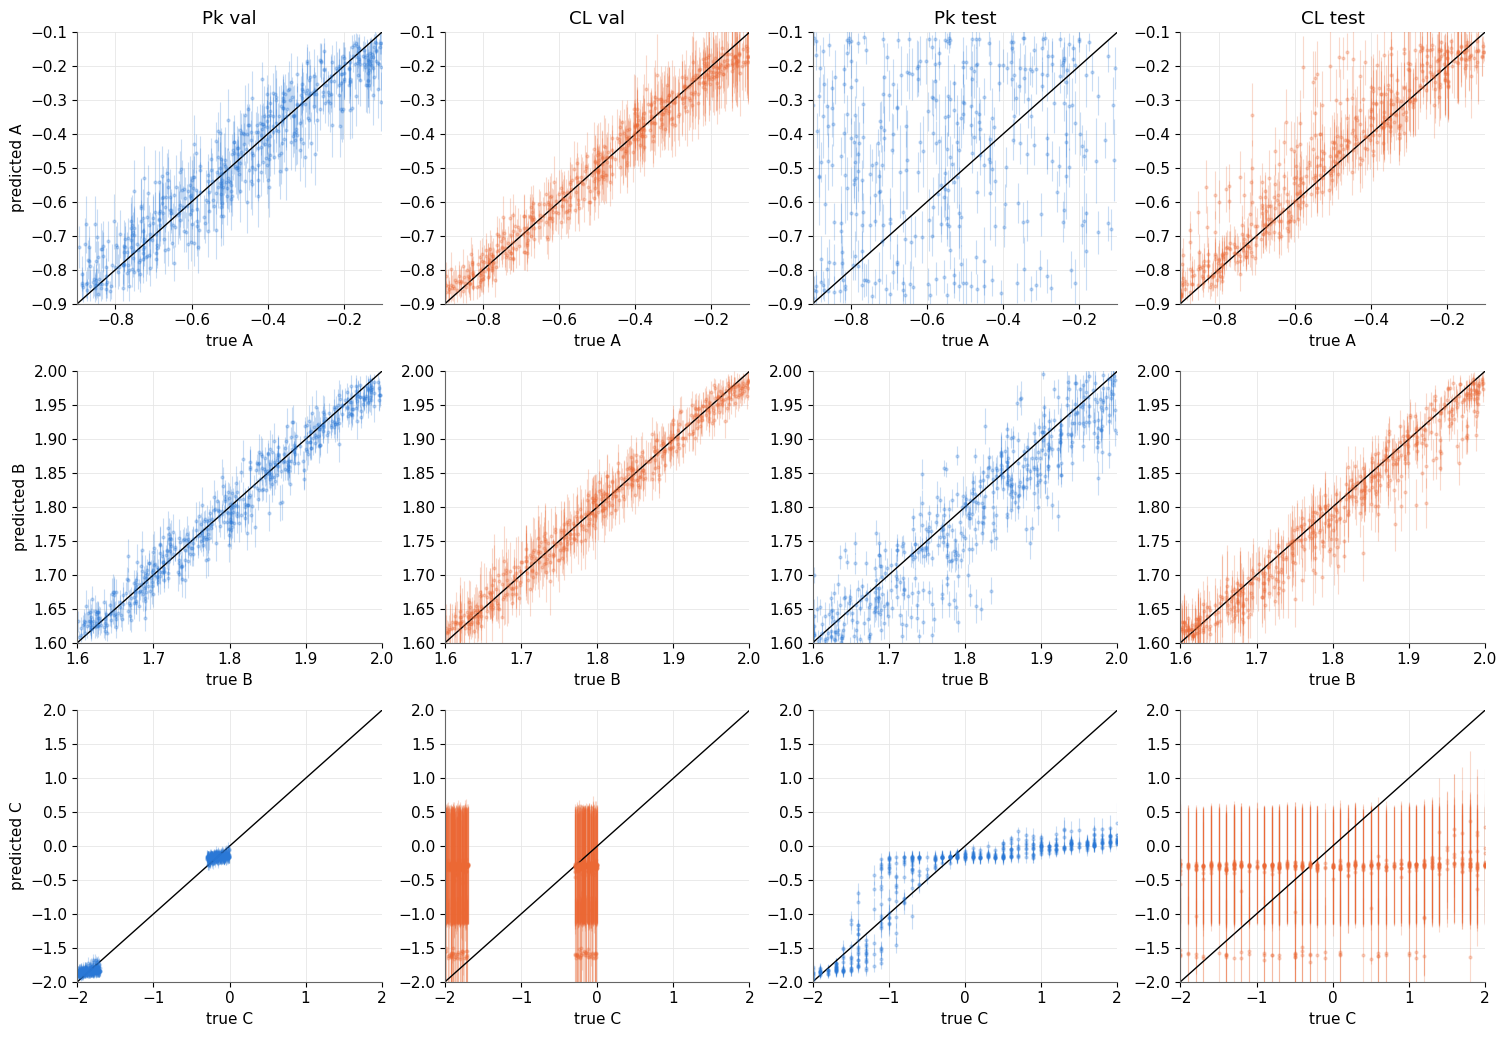

In [6]:
fig = plots.true_vs_pred(cfg, results); metrics.save_fig(cfg, fig, "compare/true_vs_pred")

## Error, width and bias distributions
The first/last bins also collect the values outside the plotted range.

PosixPath('outputs/full/compare/error_distributions.png')

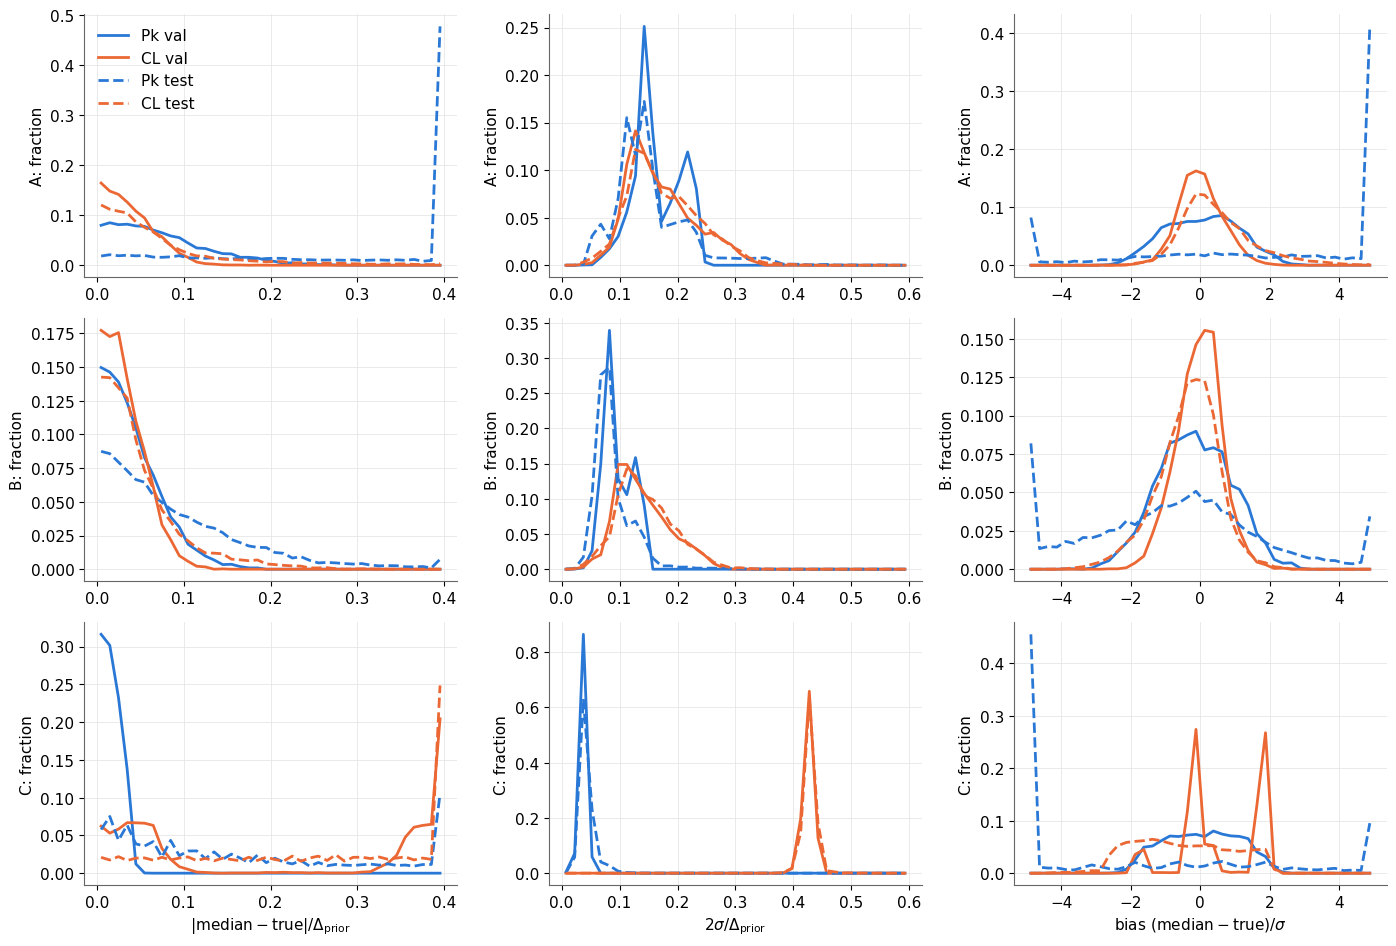

In [7]:
fig = plots.error_distributions(cfg, results); metrics.save_fig(cfg, fig, "compare/error_distributions")

## Coverage

PosixPath('outputs/full/compare/coverage.png')

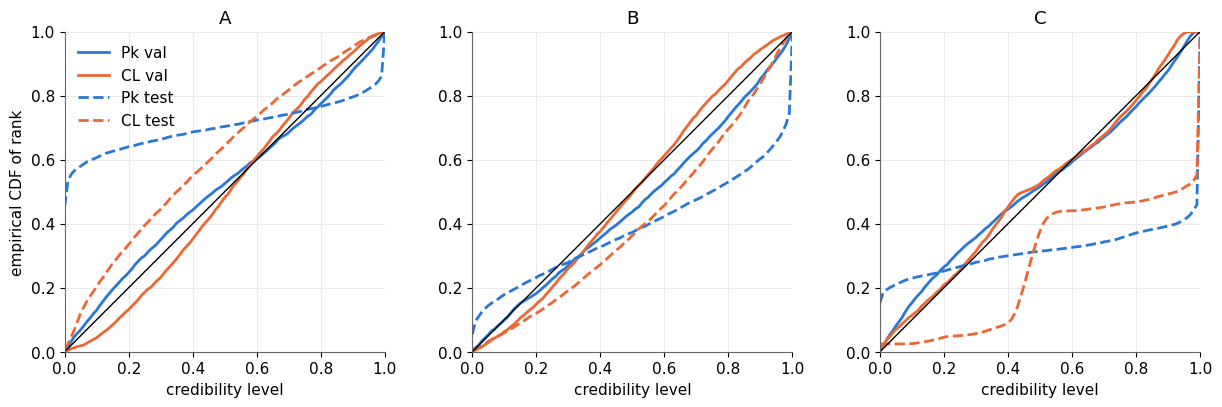

In [8]:
fig = plots.coverage(cfg, results); metrics.save_fig(cfg, fig, "compare/coverage")

## Acceptance and fallback against C

PosixPath('outputs/full/compare/fallback_vs_C.png')

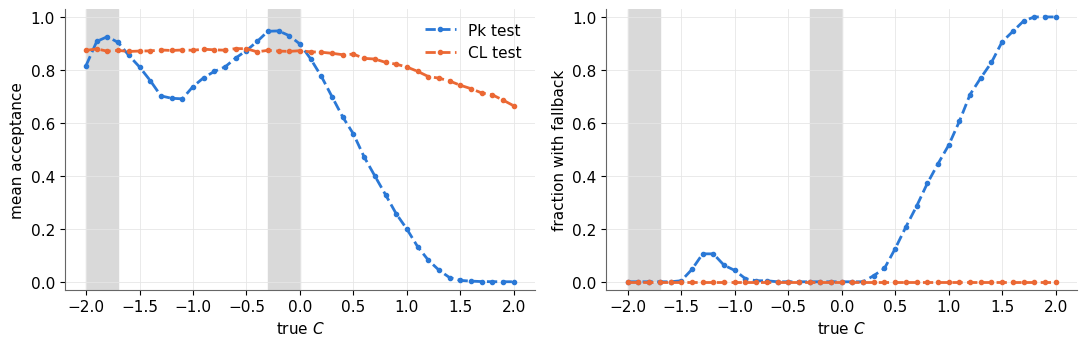

In [9]:
test = {k: v for k, v in results.items() if k.endswith("test")}
fig = plots.fallback_vs_c(cfg, test); metrics.save_fig(cfg, fig, "compare/fallback_vs_C")

## Metrics against C
The key test: the Pk posterior only saw C in the grey bands; does the CL posterior stay unbiased and calibrated for C values it never saw?

PosixPath('outputs/full/compare/metrics_vs_C.png')

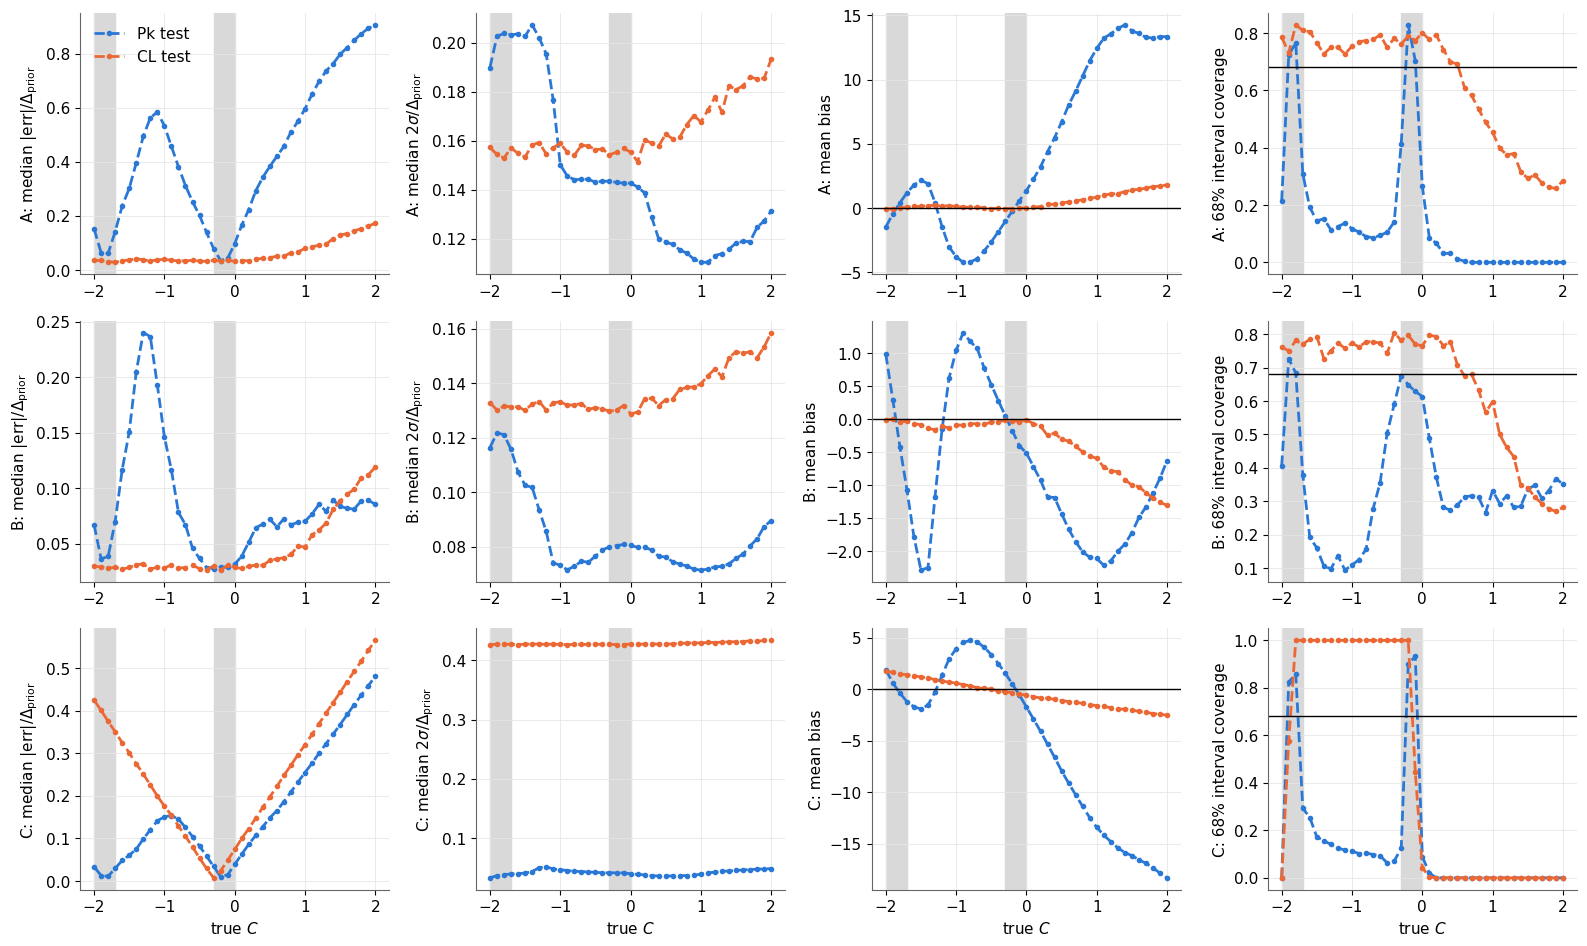

In [10]:
fig = plots.metrics_vs_c(cfg, test); metrics.save_fig(cfg, fig, "compare/metrics_vs_C")